In [1]:
import nltk
import numpy as np
import pandas as pd
import gensim

In [2]:
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer

In [3]:
from nltk.corpus import stopwords

In [4]:
import re

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss

In [7]:
from gensim.models import Word2Vec

In [8]:
snowball=SnowballStemmer(language='english')

In [9]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
stop_words=set(stopwords.words('english'))

In [11]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
data=pd.read_csv('C:\\Users\\Dell\\Desktop\\review.csv')#delimiter='\t')
data.tail(5)

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
30841,US,44834233,R366C7ARIWLN7R,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,3720,3875,N,Y,A great upgrade for me from an older Kindle Fire!,[[VIDEOID:moP3B6GS5RL8LY]]I purchased the orig...,2014-10-03,1
30842,US,13376158,R35PL0AOCUXLU9,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,2716,2849,N,Y,Great Value for $139,I'm writing this review with the benefit of be...,2014-10-03,1
30843,US,40485963,R18ZJVY86AUFII,B00KC6XV58,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,1525,1629,N,Y,Even grandma has it figured out!,"I purchased this Kindle for my grandma, becaus...",2014-10-03,1
30844,US,33485035,R36QVLQXMCZRSJ,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,143,163,N,Y,The Honda Accord of Tablets,I bought my tablet Fire HD 7 at Best Buy on th...,2014-10-03,1
30845,US,7015231,R1MWVQUDBUADGE,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,2,10,N,N,won't regret it,Am impressive piece of hardware for the $. No ...,2014-10-03,1


In [13]:
lemm=WordNetLemmatizer()

In [14]:
data['combined_text'] = data["review_headline"] + " " + data["review_body"]
df=data[['combined_text','sentiment']]
df.head(5)

,combined_text,sentiment
0,Five Stars Great love it,1
1,Lots of ads Slow processing speed Occasionally...,0
2,Well thought out device Excellent unit. The v...,1
3,Not all apps/games we were looking forward to ...,1
4,Five Stars All Amazon products continue to mee...,1


In [15]:
df=df.rename(columns={'combined_text':'reviews'})

In [16]:
df.head(5)

,reviews,sentiment
0,Five Stars Great love it,1
1,Lots of ads Slow processing speed Occasionally...,0
2,Well thought out device Excellent unit. The v...,1
3,Not all apps/games we were looking forward to ...,1
4,Five Stars All Amazon products continue to mee...,1


In [17]:
def clean_text(text):
    # Remove tokens like [[VIDEOID:...]]
    text = re.sub(r"\[\[.*?\]\]", "", text)

    # Remove HTML tags like <br/>, <div>, etc.
    text = re.sub(r"<.*?>", "", text)

    # Remove HTML entities like &#34;, &amp;, etc.
    text = re.sub(r"&[^;\s]+;", "", text)

    # Remove leftover brackets, slashes, or weird punctuation
    text = re.sub(r"[\[\]\\/]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [18]:
def data_process(orig):
    if isinstance(orig, str):  # Check if the value is a string
        clean_data = clean_text(orig.lower())  # Remove non-alphanumeric characters
    else:
        clean_data = clean_text(str(orig).lower())  # C
    tokens=word_tokenize(clean_data)
    tokens=[lemm.lemmatize(word,pos='v') for word in tokens if word.isalnum() and word not in stop_words]
    return tokens

In [19]:
df['tokenized']=df['reviews'].apply(data_process)
df.tail(5)

,reviews,sentiment,tokenized
30841,A great upgrade for me from an older Kindle Fi...,1,"[great, upgrade, older, kindle, fire, purchase..."
30842,Great Value for $139 I'm writing this review w...,1,"[great, value, 139, write, review, benefit, ex..."
30843,Even grandma has it figured out! I purchased t...,1,"[even, grandma, figure, purchase, kindle, gran..."
30844,The Honda Accord of Tablets I bought my tablet...,1,"[honda, accord, tablets, buy, tablet, fire, hd..."
30845,won't regret it Am impressive piece of hardwar...,1,"[wo, regret, impressive, piece, hardware, regr..."


In [20]:
tfidf=TfidfVectorizer(max_features=5000,ngram_range=(1,2))

In [21]:
w2v_model=Word2Vec(df['tokenized'].tolist(),vector_size=100,window=5,workers=2,min_count=1)

In [22]:
X=tfidf.fit_transform(df["tokenized"].apply(lambda tokens: " ".join(tokens)))
y=df["sentiment"]

In [23]:
def get_average_vector(token):
    avg_vec=[w2v_model.wv[word] for word in token if word in w2v_model.wv]
    return np.mean(avg_vec,axis=0) if avg_vec else np.zeros(w2v_model.vector_size)

In [24]:
Xi=np.array([get_average_vector(token) for token in df["tokenized"]])

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [26]:
model = LogisticRegression(max_iter=1000, solver='saga', verbose=1, penalty='l2')
model.fit(X_train, y_train)

convergence after 19 epochs took 0 seconds


LogisticRegression(max_iter=1000, solver='saga', verbose=1)

In [27]:
y_pred = model.predict(X_test)

In [28]:
y_proba=model.predict_proba(X_test)

In [29]:
model.classes_

array([0, 1], dtype=int64)

In [30]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 93.11%


In [31]:
conf=confusion_matrix(y_test,y_pred)
conf

array([[ 1414,   618],
       [  232, 10075]], dtype=int64)

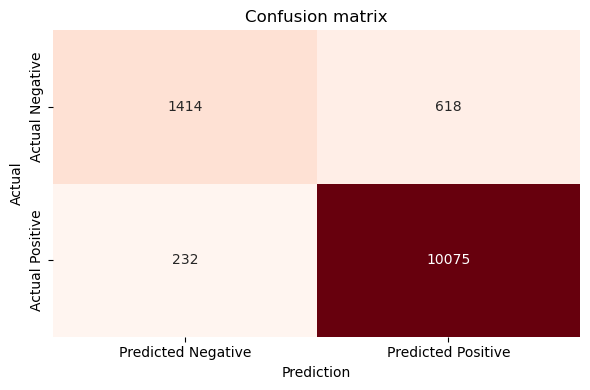

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(conf, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()

In [33]:
lloss=log_loss(y_test,y_proba)
print(f"Log Loss : {lloss}")

Log Loss : 0.1764086874862524


In [34]:
cost_function=np.mean(lloss)
print("Cost function",cost_function)

Cost function 0.1764086874862524


In [35]:
def user_input(user):
    user_token=data_process(user)
    tokenized_joined = [" ".join(user_token)]
    user_vector=tfidf.transform(tokenized_joined)
    #label= model.predict(user_vector)[0]
    proba=model.predict_proba(user_vector)[0]
    if 0.4 < proba[1] < 0.6:
        print("Model says: Neutral")
    elif proba[1] >= 0.6:
        print("Model says: Positive")
    else:
        print("Model says: Negative")

In [36]:
def user_in2(user):
    user_token=data_process(user)
    vector=get_average_vector(user_token).reshape(1, -1)
    proba=model.predict_proba(vector)[0]
    if proba[1] >= 0.6:
        print("Model says: Positive")
    elif proba[1] <= 0.4:
        print("Model says: Negative")
    else:
        print("Model is unsure. Might be neutral or mixed.")

In [40]:
user_int="not bad but good"
user_input(user_int)

Model says: Neutral
